# UV and DV PDF Neural Network Training

MSE training: `(log_x, log_Q2) -> [xf_uv(x, Q2), xf_dv(x, Q2)]`.

This notebook trains a neural network to approximate the first JAMPDF plot, focusing on the up-valence (`uv`) and down-valence (`dv`) quark distributions.

Unlike training on each replica individually, this version trains on the median of the replicas for each `(x, Q²)`. This makes the target curve smoother and helps reduce noisy or spiky loss during training. The tradeoff is that the network learns the central behavior of the PDFs, but it does not directly learn the full variance between replicas.

The model is trained on selected `Q²` values and tested on a held-out validation scale to check whether it can generalize to a value of `Q²` it did not see during training.

To make the training more reproducible, I set a random seed. Neural network training includes random initialization and random batch shuffling, so fixing the seed helps produce more consistent results across different runs.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import zipfile
import copy
import time
from google.colab import drive
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Loading the PDF dataset

In this cell, I load the PDF data from the `.zip` file.  
The file contains precomputed parton distribution function values. These values describe how quarks share the momentum inside the proton.

The object `treypdf` stores the PDF values for different values of `Q²` and for different quark flavors, such as `uv` and `dv`.

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/Summer NN/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())

    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

print("Loaded treypdf successfully.")
print("Available Q2 values:", list(treypdf.keys()))
print("Available flavors:", list(treypdf[list(treypdf.keys())[0]].keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files inside zip: ['trey24_no_sidis_lo.npy']
Loaded treypdf successfully.
Available Q2 values: [1.6129, 10, 100, 500, 1000]
Available flavors: ['uv', 'dv', 'ub', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb', 'g']


### Creating the x values

In this cell, I recreate the same `x` grid used in the original JAMPDF plot.  
The variable `x` represents the fraction of the proton's momentum carried by a quark.

The first part of the grid uses logarithmic spacing from very small `x` values to `0.4`, because PDFs change rapidly at small `x`.  
The second part uses linear spacing from `0.4` to `1`, where the behavior is less compressed.

In [5]:
X = 10**np.linspace(-4, np.log10(0.4), 100)
X = np.append(X, np.linspace(0.4, 1, 101)[1:])

Q2_vals = [1.6129, 10, 100, 500, 1000]

N_x = len(X)

print("Number of x values:", N_x)
print("x min:", X.min())
print("x max:", X.max())

Number of x values: 200
x min: 0.0001
x max: 1.0


### Checking the shape of the data

In this cell, I check the shape of the `uv` and `dv` arrays.  
Here, `uv` means up-valence quark distribution, and `dv` means down-valence quark distribution.

The rows represent PDF replicas, which are different possible versions of the same distribution.  
The columns correspond to the different `x` values.  
This helps confirm how the data is organized before training the neural network.

In [6]:
q2_test = Q2_vals[0]

uv_sample = treypdf[q2_test]['uv']
dv_sample = treypdf[q2_test]['dv']

print("uv shape:", uv_sample.shape)
print("dv shape:", dv_sample.shape)

N_replicas, N_x = uv_sample.shape

print("Number of replicas:", N_replicas)
print("Number of x points:", N_x)

uv shape: (1196, 200)
dv shape: (1196, 200)
Number of replicas: 1196
Number of x points: 200


### Preparing the training and validation data

In this cell, I prepare the data for supervised learning.  
The neural network will receive two inputs: `log(x)` and `log(Q²)`.  
It will learn to predict two outputs: the median `uv` value and the median `dv` value.

I use the median of the replicas because each replica is a possible version of the PDF.  
The median gives a central curve that is easier for the network to learn.

I also hold out `Q² = 500` for validation.  
This means the model trains on the other `Q²` values and is then tested on a value it has not directly seen during training.

In [7]:
VAL_Q2 = 500.0

log_x = np.log(X)

train_inputs = []
train_targets = []

val_inputs = []
val_targets = []

for q2 in Q2_vals:
    uv = treypdf[q2]['uv']   # shape: (N_replicas, N_x)
    dv = treypdf[q2]['dv']   # shape: (N_replicas, N_x)

    # Median curve across replicas
    uv_median = np.median(uv, axis=0)
    dv_median = np.median(dv, axis=0)

    # Input: [log(x), log(Q2)]
    inputs = np.stack([
        log_x,
        np.full_like(log_x, np.log(q2))
    ], axis=1)

    # Target: [uv, dv]
    targets = np.stack([
        uv_median,
        dv_median
    ], axis=1)

    if q2 == VAL_Q2:
        val_inputs.append(inputs)
        val_targets.append(targets)
    else:
        train_inputs.append(inputs)
        train_targets.append(targets)

train_X = torch.tensor(np.concatenate(train_inputs), dtype=torch.float32).to(device)
train_Y = torch.tensor(np.concatenate(train_targets), dtype=torch.float32).to(device)

val_X = torch.tensor(np.concatenate(val_inputs), dtype=torch.float32).to(device)
val_Y = torch.tensor(np.concatenate(val_targets), dtype=torch.float32).to(device)

print("train_X:", train_X.shape)
print("train_Y:", train_Y.shape)
print("val_X:", val_X.shape)
print("val_Y:", val_Y.shape)

train_X: torch.Size([800, 2])
train_Y: torch.Size([800, 2])
val_X: torch.Size([200, 2])
val_Y: torch.Size([200, 2])


### Defining the neural network

In this cell, I define the neural network architecture.  
The model takes two inputs: `log(x)` and `log(Q²)`.  
It outputs two values: the predicted `uv` and `dv` distributions.

The hidden layers allow the model to learn nonlinear relationships between the input variables and the PDF values.  
The final layer has two outputs because the model predicts both the up-valence and down-valence distributions.

The `Softplus` activation is used at the end to keep the predictions positive, which makes sense because PDF values should not be negative.

In [8]:
class PDFNN(nn.Module):
    """
    Input:  [log(x), log(Q2)]
    Output: [xf_uv(x,Q2), xf_dv(x,Q2)]
    """

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 128),
            nn.Tanh(),

            nn.Linear(128, 64),
            nn.Tanh(),

            nn.Linear(64, 2),
            nn.Softplus()
        )

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


model = PDFNN().to(device)

print(model)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

PDFNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=2, bias=True)
    (7): Softplus(beta=1.0, threshold=20.0)
  )
)
Number of parameters: 16898


### Training the neural network

In this cell, I train the neural network.  
During training, the model makes predictions, compares them with the true median PDF values, calculates the error, and updates its weights to reduce that error.

The loss function used is mean squared error, which measures the absolute difference between the predicted and true `uv` and `dv` values. Standard MSE is useful for training the model on the central PDF curve, but it can give more importance to regions where the PDF values are larger. A possible future improvement is to test a relative MSE loss to reduce this bias

I also use validation loss to track how well the model performs on `Q² = 500`, which was not used during training.  
Early stopping prevents unnecessary training if the validation loss stops improving.

In [26]:
BATCH_SIZE = 512
N_EPOCHS = 10000
LOG_EVERY = 500
EARLY_STOP_PATIENCE = 1500

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=300,
    min_lr=1e-6
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
no_improve = 0

N_train = train_X.shape[0]
n_batches = (N_train + BATCH_SIZE - 1) // BATCH_SIZE

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    model.train()

    permutation = torch.randperm(N_train, device=device)
    epoch_loss = 0.0

    for start in range(0, N_train, BATCH_SIZE):
        indices = permutation[start:start + BATCH_SIZE]

        xb = train_X[indices]
        yb = train_Y[indices]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / n_batches

    model.eval()
    with torch.no_grad():
        val_pred = model(val_X)
        val_loss = loss_fn(val_pred, val_Y).item()

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    if epoch % LOG_EVERY == 0:
        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:5d} | "
            f"Train Loss: {train_loss:.6e} | "
            f"Val Loss: {val_loss:.6e} | "
            f"Time: {elapsed:.1f}s"
        )

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print("Best validation loss:", best_val_loss)

Epoch   500 | Train Loss: 1.642990e-05 | Val Loss: 1.150380e-05 | Time: 3.4s
Epoch  1000 | Train Loss: 1.466939e-05 | Val Loss: 7.555622e-06 | Time: 6.2s
Epoch  1500 | Train Loss: 3.733607e-05 | Val Loss: 2.024547e-05 | Time: 10.1s
Epoch  2000 | Train Loss: 1.528867e-05 | Val Loss: 8.332059e-06 | Time: 13.4s
Epoch  2500 | Train Loss: 1.382263e-05 | Val Loss: 7.105672e-06 | Time: 16.2s
Epoch  3000 | Train Loss: 1.372162e-05 | Val Loss: 7.009441e-06 | Time: 19.0s
Epoch  3500 | Train Loss: 1.378781e-05 | Val Loss: 6.751718e-06 | Time: 22.0s
Epoch  4000 | Train Loss: 1.406983e-05 | Val Loss: 7.220749e-06 | Time: 26.2s
Epoch  4500 | Train Loss: 1.403726e-05 | Val Loss: 6.778003e-06 | Time: 29.1s
Early stopping at epoch 4632
Best validation loss: 6.53780807624571e-06


### Plotting the training and validation loss

In this cell, I plot the training loss and validation loss.  
This helps show whether the neural network is learning.

If both losses decrease, the model is improving.  
If the training loss decreases but the validation loss gets worse, that may indicate overfitting.

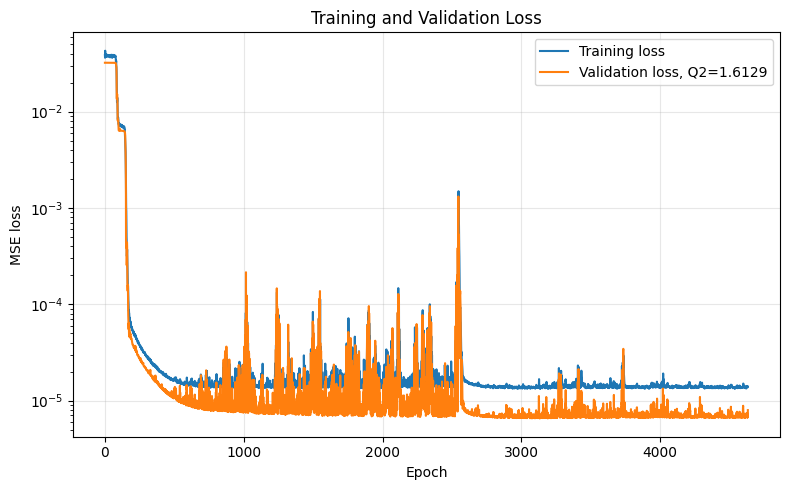

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label=f"Validation loss, Q2={VAL_Q2}")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparing the neural network with the original PDF bands

In this cell, I compare the neural network predictions with the original PDF data for all selected `Q²` values.

The shaded regions represent the uncertainty bands from the PDF replicas.  
The median curves represent the central PDF values.  
The neural network curves show the model predictions.

This plot helps visually check whether the neural network has learned the general shape of the `uv` and `dv` distributions.

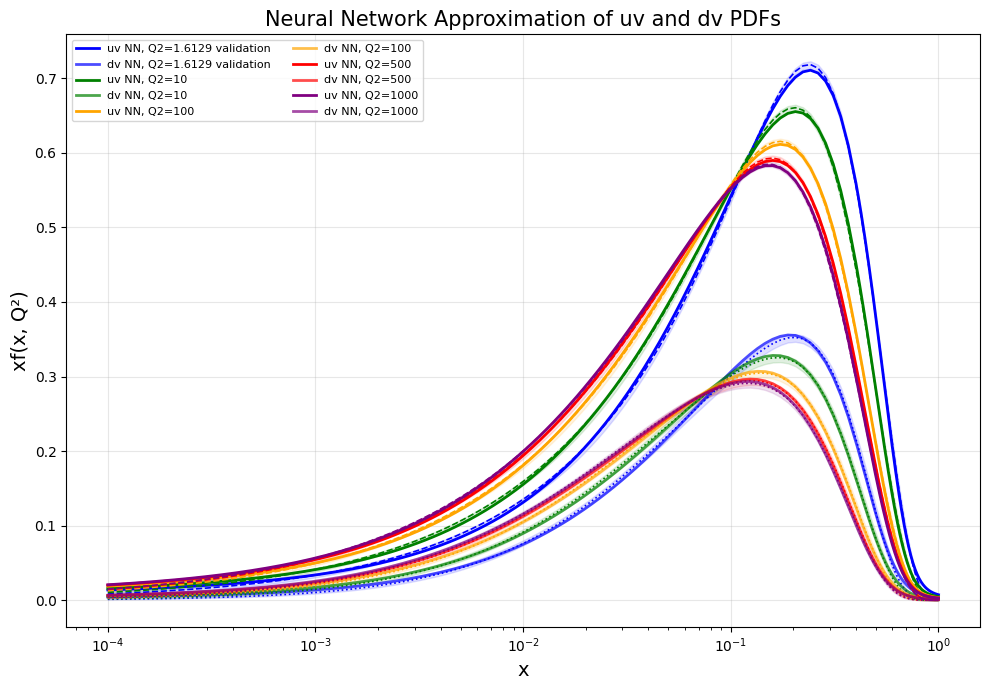

In [28]:
model.eval()

colors = {
    1.6129: "blue",
    10: "green",
    100: "orange",
    500: "red",
    1000: "purple"
}

fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:

    color = colors[q2]

    uv = treypdf[q2]['uv']
    dv = treypdf[q2]['dv']

    uv_lower = np.quantile(uv, 0.025, axis=0)
    uv_upper = np.quantile(uv, 0.975, axis=0)
    uv_median = np.median(uv, axis=0)

    dv_lower = np.quantile(dv, 0.025, axis=0)
    dv_upper = np.quantile(dv, 0.975, axis=0)
    dv_median = np.median(dv, axis=0)

    # Inputs for this Q2
    inputs = np.stack([
        np.log(X),
        np.full_like(X, np.log(q2))
    ], axis=1)

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(inputs_tensor).cpu().numpy()

    uv_pred = prediction[:, 0]
    dv_pred = prediction[:, 1]

    val_label = " validation" if q2 == VAL_Q2 else ""

    # UV band and prediction
    ax.fill_between(X, uv_lower, uv_upper, color=color, alpha=0.12)
    ax.plot(X, uv_median, color=color, linestyle="--", linewidth=1.2)
    ax.plot(X, uv_pred, color=color, linewidth=2, label=f"uv NN, Q2={q2}{val_label}")

    # DV band and prediction
    ax.fill_between(X, dv_lower, dv_upper, color=color, alpha=0.12)
    ax.plot(X, dv_median, color=color, linestyle=":", linewidth=1.2)
    ax.plot(X, dv_pred, color=color, linewidth=2, alpha=0.7, label=f"dv NN, Q2={q2}{val_label}")

ax.set_xscale("log")
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("xf(x, Q²)", fontsize=14)
ax.set_title("Neural Network Approximation of uv and dv PDFs", fontsize=15)

ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### Detailed comparison at one Q² value

In this cell, I focus on one value of `Q²`, usually `Q² = 500`.  
This is useful because `Q² = 500` was used as the validation scale, meaning the model did not train directly on it.

The plot compares the real PDF uncertainty bands, the median curves, and the neural network predictions for both `uv` and `dv`.

This gives a clearer view of how well the model generalizes to a new energy scale.

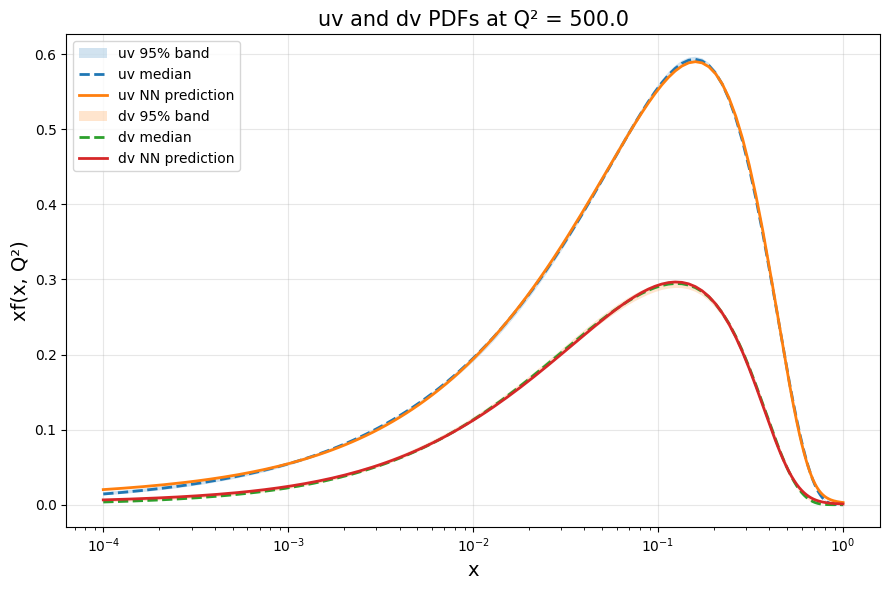

In [29]:
q2 = 500.0

model.eval()

uv = treypdf[q2]['uv']
dv = treypdf[q2]['dv']

uv_lower = np.quantile(uv, 0.025, axis=0)
uv_upper = np.quantile(uv, 0.975, axis=0)
uv_median = np.median(uv, axis=0)

dv_lower = np.quantile(dv, 0.025, axis=0)
dv_upper = np.quantile(dv, 0.975, axis=0)
dv_median = np.median(dv, axis=0)

inputs = np.stack([
    np.log(X),
    np.full_like(X, np.log(q2))
], axis=1)

inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

with torch.no_grad():
    prediction = model(inputs_tensor).cpu().numpy()

uv_pred = prediction[:, 0]
dv_pred = prediction[:, 1]

plt.figure(figsize=(9, 6))

plt.fill_between(X, uv_lower, uv_upper, alpha=0.2, label="uv 95% band")
plt.plot(X, uv_median, linestyle="--", linewidth=2, label="uv median")
plt.plot(X, uv_pred, linewidth=2, label="uv NN prediction")

plt.fill_between(X, dv_lower, dv_upper, alpha=0.2, label="dv 95% band")
plt.plot(X, dv_median, linestyle="--", linewidth=2, label="dv median")
plt.plot(X, dv_pred, linewidth=2, label="dv NN prediction")

plt.xscale("log")
plt.xlabel("x", fontsize=14)
plt.ylabel("xf(x, Q²)", fontsize=14)
plt.title(f"uv and dv PDFs at Q² = {q2}", fontsize=15)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Measuring prediction coverage inside the uncertainty band

In this cell, I calculate how often the neural network prediction falls inside the 95% PDF uncertainty band.

This gives a quantitative measure of performance.  
Instead of only checking visually, I can measure whether the model's predictions are consistent with the range of possible PDF replicas.

A high percentage means the neural network prediction is often within the uncertainty band.

In [30]:
model.eval()

print("Percentage of NN predictions inside the 95% PDF band")
print()
print(f"{'Q2':>10} | {'uv coverage':>12} | {'dv coverage':>12}")
print("-" * 42)

for q2 in Q2_vals:

    uv = treypdf[q2]['uv']
    dv = treypdf[q2]['dv']

    uv_lower = np.quantile(uv, 0.025, axis=0)
    uv_upper = np.quantile(uv, 0.975, axis=0)

    dv_lower = np.quantile(dv, 0.025, axis=0)
    dv_upper = np.quantile(dv, 0.975, axis=0)

    inputs = np.stack([
        np.log(X),
        np.full_like(X, np.log(q2))
    ], axis=1)

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(inputs_tensor).cpu().numpy()

    uv_pred = prediction[:, 0]
    dv_pred = prediction[:, 1]

    uv_coverage = np.mean((uv_pred >= uv_lower) & (uv_pred <= uv_upper)) * 100
    dv_coverage = np.mean((dv_pred >= dv_lower) & (dv_pred <= dv_upper)) * 100

    print(f"{q2:>10} | {uv_coverage:>11.1f}% | {dv_coverage:>11.1f}%")

Percentage of NN predictions inside the 95% PDF band

        Q2 |  uv coverage |  dv coverage
------------------------------------------
    1.6129 |        40.0% |        41.5%
        10 |        39.0% |        47.0%
       100 |        47.0% |        52.0%
       500 |        50.5% |        52.5%
      1000 |        53.5% |        53.0%


The coverage results show that the neural network prediction falls inside the 95% replica uncertainty band only about 40–53% of the time. This means that, although the model captures the general PDF shape visually, it does not consistently remain within the uncertainty range suggested by the replicas. Coverage improves at larger Q² values, while the lowest scale, Q² = 1.6129, has the weakest performance. This supports the later observation that the model has more difficulty generalizing at low Q².

### Error analysis as a function of x

To improve the evaluation, I analyze the absolute error between the neural network prediction and the median PDF curve as a function of `x`. This helps identify whether the model struggles more at small, intermediate, or large momentum fractions.

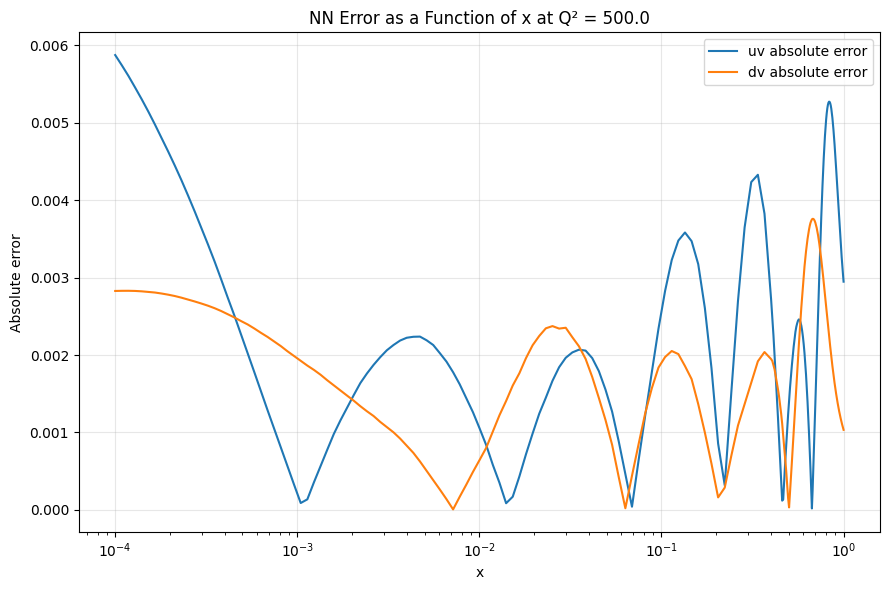

In [31]:
q2 = 500.0

model.eval()

uv = treypdf[q2]['uv']
dv = treypdf[q2]['dv']

uv_median = np.median(uv, axis=0)
dv_median = np.median(dv, axis=0)

inputs = np.stack([
    np.log(X),
    np.full_like(X, np.log(q2))
], axis=1)

inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)

with torch.no_grad():
    prediction = model(inputs_tensor).cpu().numpy()

uv_pred = prediction[:, 0]
dv_pred = prediction[:, 1]

# Absolute error
uv_abs_error = np.abs(uv_pred - uv_median)
dv_abs_error = np.abs(dv_pred - dv_median)

plt.figure(figsize=(9, 6))

plt.plot(X, uv_abs_error, label="uv absolute error")
plt.plot(X, dv_abs_error, label="dv absolute error")

plt.xscale("log")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title(f"NN Error as a Function of x at Q² = {q2}")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Error analysis as a function of x

The error plot shows that the neural network does not perform uniformly across all values of `x`.

The largest errors appear near the edges of the domain, especially at very small `x` and close to `x = 1`. This suggests that the model captures the general shape of the PDFs, but it struggles more at the boundaries.

The `uv` prediction generally has a larger absolute error than the `dv` prediction, meaning that the up-valence distribution may be harder for the network to approximate accurately.

This analysis improves the evaluation because it shows not only whether the prediction looks visually close, but also where the model makes its largest mistakes.

### Leave-one-Q²-out validation

To test the model more strongly, I repeat the validation by holding out each Q² value one at a time. This checks whether the neural network can generalize across different energy scales, instead of only being tested at Q² = 500.

In [32]:
# Leave-one-Q²-out validation

N_EPOCHS_CV = 3000
BATCH_SIZE_CV = 512

validation_results = {}

for VAL_Q2 in Q2_vals:
    print(f"\nTraining with validation Q² = {VAL_Q2}")

    train_inputs = []
    train_targets = []
    val_inputs = []
    val_targets = []

    log_x = np.log(X)

    # Rebuild train/validation data for this held-out Q²
    for q2 in Q2_vals:
        uv = treypdf[q2]['uv']
        dv = treypdf[q2]['dv']

        uv_median = np.median(uv, axis=0)
        dv_median = np.median(dv, axis=0)

        inputs = np.stack([
            log_x,
            np.full_like(log_x, np.log(q2))
        ], axis=1)

        targets = np.stack([
            uv_median,
            dv_median
        ], axis=1)

        if q2 == VAL_Q2:
            val_inputs.append(inputs)
            val_targets.append(targets)
        else:
            train_inputs.append(inputs)
            train_targets.append(targets)

    train_X_cv = torch.tensor(np.concatenate(train_inputs), dtype=torch.float32).to(device)
    train_Y_cv = torch.tensor(np.concatenate(train_targets), dtype=torch.float32).to(device)

    val_X_cv = torch.tensor(np.concatenate(val_inputs), dtype=torch.float32).to(device)
    val_Y_cv = torch.tensor(np.concatenate(val_targets), dtype=torch.float32).to(device)

    # Fresh model for each validation Q²
    model_cv = PDFNN().to(device)

    optimizer = optim.Adam(model_cv.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None

    N_train = train_X_cv.shape[0]

    for epoch in range(N_EPOCHS_CV):
        model_cv.train()

        permutation = torch.randperm(N_train, device=device)

        for start in range(0, N_train, BATCH_SIZE_CV):
            indices = permutation[start:start + BATCH_SIZE_CV]

            xb = train_X_cv[indices]
            yb = train_Y_cv[indices]

            optimizer.zero_grad()
            pred = model_cv(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model_cv.eval()
        with torch.no_grad():
            val_pred = model_cv(val_X_cv)
            val_loss = loss_fn(val_pred, val_Y_cv).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_cv.state_dict())

    validation_results[VAL_Q2] = best_val_loss
    print(f"Best validation loss for Q² = {VAL_Q2}: {best_val_loss:.6e}")


print("\nFinal leave-one-Q²-out results:")
for q2, loss in validation_results.items():
    print(f"Validation Q² = {q2}: loss = {loss:.6e}")


Training with validation Q² = 1.6129
Best validation loss for Q² = 1.6129: 3.345845e-03

Training with validation Q² = 10
Best validation loss for Q² = 10: 2.095359e-05

Training with validation Q² = 100
Best validation loss for Q² = 100: 1.275509e-05

Training with validation Q² = 500
Best validation loss for Q² = 500: 8.867960e-06

Training with validation Q² = 1000
Best validation loss for Q² = 1000: 7.734173e-06

Final leave-one-Q²-out results:
Validation Q² = 1.6129: loss = 3.345845e-03
Validation Q² = 10: loss = 2.095359e-05
Validation Q² = 100: loss = 1.275509e-05
Validation Q² = 500: loss = 8.867960e-06
Validation Q² = 1000: loss = 7.734173e-06


The leave-one-Q²-out validation shows that the model generalizes well for most energy scales, especially for Q² = 100, 500, and 1000, where the validation losses are around 10⁻⁵. However, the loss is much larger when Q² = 1.6129 is held out. This suggests that the lowest Q² value is harder for the neural network to predict because, in that case, the model must extrapolate below the training range instead of interpolating between known Q² values.

This result shows why testing only one validation scale is limited. Although the model performs well at Q² = 500, the leave-one-Q²-out test reveals that performance depends on which energy scale is excluded.

### Saving the trained model

This cell saves the trained neural network so it can be reused later without retraining.

In [33]:
save_path = "/content/drive/MyDrive/uv_dv_pdf_nn_model.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "Q2_vals": Q2_vals,
    "VAL_Q2": VAL_Q2,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "notes": "NN trained on median uv and dv valence PDFs from trey24_no_sidis_lo.npy"
}, save_path)

print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/uv_dv_pdf_nn_model.pt


### Conclusion

The neural network captures the general behavior of the `uv` and `dv` valence PDFs, especially at intermediate and high Q² values. However, the coverage and error analysis show that the model does not perform uniformly across all x regions. The leave-one-Q²-out validation also shows that the lowest Q² scale is the hardest to generalize to, suggesting that the model has more difficulty extrapolating outside the training range than interpolating between known energy scales.